# Retail Customer Analysis Summative Lab
## Understanding Customer Behavior Across Store Locations

### Introduction

This summative lab bridges the concepts and techniques learned throughout the course with their practical application to a real-world industry scenario. You will step into the role of a junior data analyst for a retail company and apply your skills to evaluate customer behavior, satisfaction, and promotional impacts. By following the outlined process, you will gain experience in experimental design, statistical testing, and actionable decision-making.

Your task is not only to conduct the analysis but also to reflect on how these techniques help solve real-world problems that businesses face daily.

By completing this lab, you will have:
- Practiced designing and executing statistical analyses in a real-world scenario.
- Reinforced your understanding of test selection and assumptions.
- Applied statistical results to business decision-making.
- Developed skills in communicating insights effectively through visualizations and reports.

### Business Scenario Questions:
Imagine you are a junior data analyst working for a retail company that operates stores in three distinct regions: City Center, Suburb, and Rural. Your manager has tasked you with analyzing customer behavior and preferences across these locations. The goal is to help the company answer two key questions:
1. Do customer spending patterns, satisfaction levels, and product preferences differ across store locations?
2. Do promotional periods result in significantly higher spending compared to non-promotional periods?

Spending Across Location:

- Business-relevant MDE: Absolute difference in spending of 15% or more
- Justification: This represents enough of a difference to warrant location-specific strategies (inventory, staffing, etc.)


Ratings Across Locations:

- Business-relevant MDE: 1.0 point difference between locations
- Justification: On a 10-point scale, a one point difference is noticeable and actionable for customer service improvements

Promotional Spending:

- Business-relevant MDE: A $15 increase from non-promotional periods
- Justification: Promotional costs typically reduce margins by ~15-20%. Need at least 25% increase in spending to justify promotional costs. This aligns with industry standards for promotional ROI

Your task involves designing and conducting an analysis using the provided dataset to derive actionable insights. You will apply statistical concepts and techniques such as experimental design, test selection, hypothesis testing, and result interpretation. This process mimics real-world industry scenarios where junior analysts evaluate business performance using data.

The data focuses on four variables:
- Amount spent by customers (in dollars)
- Customer satisfaction ratings (scale of 1 to 10)
- Product category preferences (Electronics, Clothing, Groceries)
- Purchase type (Promotional vs. Non-Promotional)

Your analysis will inform decision-making around marketing strategies, store operations, and promotional campaigns.

### Setup

In this cell, import all the libraries you'll need for your analysis. Consider which libraries you'll need for:
- Data manipulation
- Statistical analysis
- Data visualization

In [1]:
# Import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import matplotlib.gridspec as gridspec
from itertools import combinations
import warnings

c:\Users\Getrude Kusa Echoka\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Getrude Kusa Echoka\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### Part 1: Experimental Design

#### 1.1 Hypothesis Formulation

For each of the following analyses, state your null and alternative hypotheses in both statistical and plain language:

1. Spending across store locations
2. Customer satisfaction across locations
3. Promotional vs non-promotional spending
4. Product category preferences across locations

1. Spending Across Store Locations

**Null Hypothesis (H₀):**  
There is no statistically significant difference in customer spending across City Center, Suburb, and Rural store locations.

**Statistical Form:**  
H₀: The distribution/median of Amount_Spent is the same across all store locations.

**Alternative Hypothesis (H₁):**  
There is a statistically significant difference in customer spending across at least one store location.

**Statistical Form:**  
H₁: At least one store location has a different distribution/median of Amount_Spent.

**Plain Language:**  
Customers spend similar amounts regardless of whether they shop in City Center, Suburb, or Rural stores. The alternative is that spending patterns differ by location.


#### 2. Customer Satisfaction Across Store Locations

**Null Hypothesis (H₀):**  
There is no statistically significant difference in customer satisfaction ratings across City Center, Suburb, and Rural store locations.

**Statistical Form:**  
H₀: The distribution/median of Customer_Satisfaction is the same across all store locations.

**Alternative Hypothesis (H₁):**  
There is a statistically significant difference in customer satisfaction ratings across at least one store location.

**Statistical Form:**  
H₁: At least one store location has a different distribution/median of Customer_Satisfaction.

**Plain Language:**  
Customers are equally satisfied across all store locations. The alternative is that satisfaction levels vary depending on the store location.


#### 3. Promotional vs Non-Promotional Spending

**Null Hypothesis (H₀):**  
There is no statistically significant difference in spending between promotional and non-promotional purchases.

**Statistical Form:**  
H₀: The distribution/median of Amount_Spent is the same for Promotional and Non-Promotional purchases.

**Alternative Hypothesis (H₁):**  
There is a statistically significant difference in spending between promotional and non-promotional purchases.

**Statistical Form:**  
H₁: The distribution/median of Amount_Spent differs between Promotional and Non-Promotional purchases.

**Plain Language:**  
Customers spend the same amount whether there is a promotion or not. The alternative is that promotional periods are associated with different customer spending levels.


#### 4. Product Category Preferences Across Store Locations

**Null Hypothesis (H₀):**  
Product category preference is independent of store location.

**Statistical Form:**  
H₀: Store_Location and Product_Category are independent.

**Alternative Hypothesis (H₁):**  
Product category preference is associated with store location.

**Statistical Form:**  
H₁: Store_Location and Product_Category are not independent.

**Plain Language:**  
Customers in City Center, Suburb, and Rural stores have similar product category preferences. The alternative is that product preferences differ depending on store location.

**Reflective Question: Explain the concept of Minimum Detectable Effect (MDE) and why it is important.**

Minimum Detectable Effect (MDE) refers to the smallest difference or effect size that is considered meaningful enough for the business to act on. It is not only about whether a result is statistically significant, but whether the difference is large enough to matter in practical decision-making.

In this retail customer analysis, the MDE helps connect statistical testing to business relevance. For spending across locations, the business-relevant MDE is a difference of 15% or more. This means that even if spending differences are statistically significant, they should only influence location-specific strategies such as staffing, inventory allocation, or pricing if the difference is large enough to justify action. For customer satisfaction, the MDE is a 1.0-point difference on a 10-point scale because such a gap is noticeable and may require customer service improvements. For promotional spending, the MDE is a $15 increase because promotions usually reduce profit margins, so the company needs a large enough spending increase to justify the promotional cost.

MDE is important because large datasets can produce statistically significant results even when the actual difference is too small to be useful. At the same time, small samples may fail to detect real business effects. By defining the MDE before analysis, the company avoids overreacting to minor statistical differences and focuses instead on findings that are both statistically valid and commercially meaningful.


### Part 2: Data Exploration

#### 2.1 Load and Examine the Dataset

Load the dataset and perform initial data quality checks:
- Check for missing values
- Examine data types
- Look for inconsistencies
- Generate summary statistics

In [2]:
# Load Data
df= pd.read_csv("retail_store_customer_data.csv", index_col= False)

# check for missing values
print("\n" + "=" * 60)
print("Missing Values")
print("=" * 60)
print(df.isnull().sum())

# check the data types
print("\n" + "=" * 60)
print("Data Types")
print("=" * 60)
print(df.dtypes)

# check for inconsistencies
print("=" * 60)
print("1. BASIC DATASET INFO")
print("=" * 60)
print(df.info())

# check for duplicates
print("\n" + "=" * 60)
print("3. DUPLICATE ROWS")
print("=" * 60)
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")
if duplicates > 0:
    print(df[df.duplicated(keep=False)])  # shows all duplicate rows

# check for shape
print("\n" + "=" * 60)
print("Shape")
print("=" * 60)
print(df.shape)

# check for unique values
print("\n" + "=" * 60)
print("CHECKING UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("=" * 60)
categorical_cols = df.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    print(f"\n{col} — {df[col].nunique()} unique values:")
    print(df[col].value_counts())

# check summary statistics
print("\n" + "=" * 60)
print("Summary Statistics")
print("=" * 60)
print(df.describe())


Missing Values
Store_Location           0
Customer_Satisfaction    0
Product_Category         0
Purchase_Type            0
Amount_Spent             0
dtype: int64

Data Types
Store_Location               str
Customer_Satisfaction    float64
Product_Category             str
Purchase_Type                str
Amount_Spent             float64
dtype: object
1. BASIC DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store_Location         1500 non-null   str    
 1   Customer_Satisfaction  1500 non-null   float64
 2   Product_Category       1500 non-null   str    
 3   Purchase_Type          1500 non-null   str    
 4   Amount_Spent           1500 non-null   float64
dtypes: float64(2), str(3)
memory usage: 102.0 KB
None

3. DUPLICATE ROWS
Total duplicate rows: 0

Shape
(1500, 5)

CHECKING UNIQUE VALUES IN CATEGORICAL COLUMNS

S

C:\Users\Getrude Kusa Echoka\AppData\Local\Temp\ipykernel_17116\3614781332.py:41: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


#### 2.2 Data Visualizations

Create visualizations to understand the distribution of key variables:
- Spending patterns across locations
- Satisfaction ratings distribution
- Product category preferences
- Promotional vs non-promotional spending

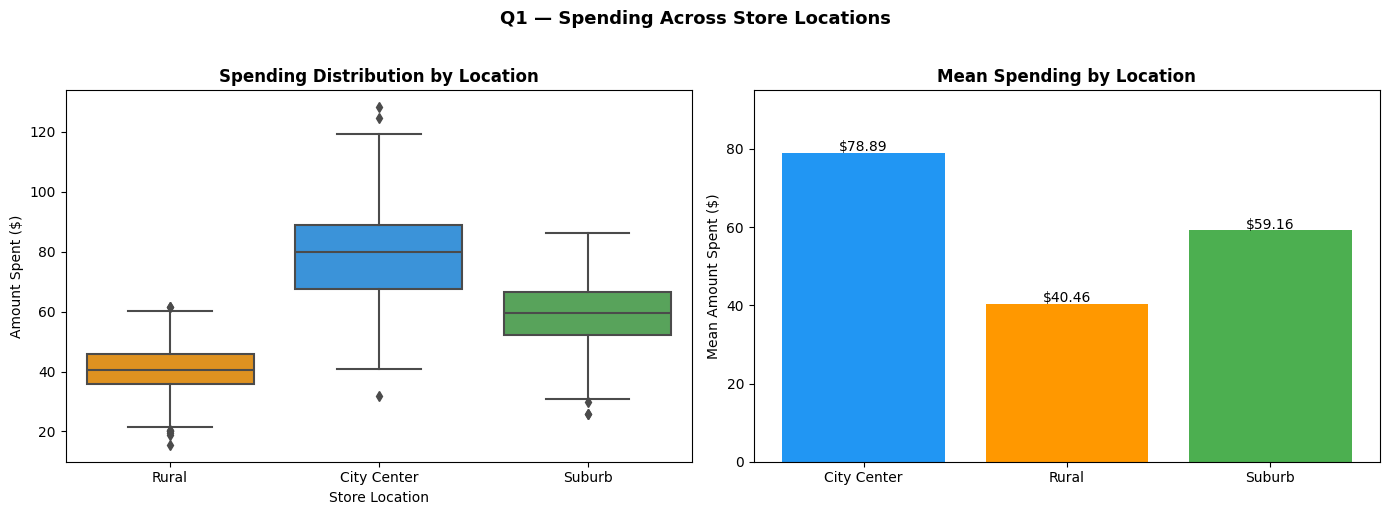

In [ ]:
# Visualize data - Create new cells as needed
# Conducting analysis of spending patterns here
# VIZ 1: Spending patterns across locations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {'City Center': '#2196F3', 'Suburb': '#4CAF50', 'Rural': '#FF9800'}

# Box plot
sns.boxplot(data=df, x='Store_Location', y='Amount_Spent',
            palette=palette, ax=axes[0])
axes[0].set_title('Spending Distribution by Location', fontweight='bold')
axes[0].set_xlabel('Store Location')
axes[0].set_ylabel('Amount Spent ($)')

# Mean bar chart
means = df.groupby('Store_Location')['Amount_Spent'].mean().reset_index()
bars = axes[1].bar(means['Store_Location'], means['Amount_Spent'],
                   color=[palette[l] for l in means['Store_Location']], edgecolor='none')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'${bar.get_height():.2f}', ha='center', fontsize=10)
axes[1].set_title('Mean Spending by Location', fontweight='bold')
axes[1].set_ylabel('Mean Amount Spent ($)')
axes[1].set_ylim(0, 95)

plt.suptitle('Q1 — Spending Across Store Locations', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_01_spending_location.png', dpi=150, bbox_inches='tight')
plt.show()

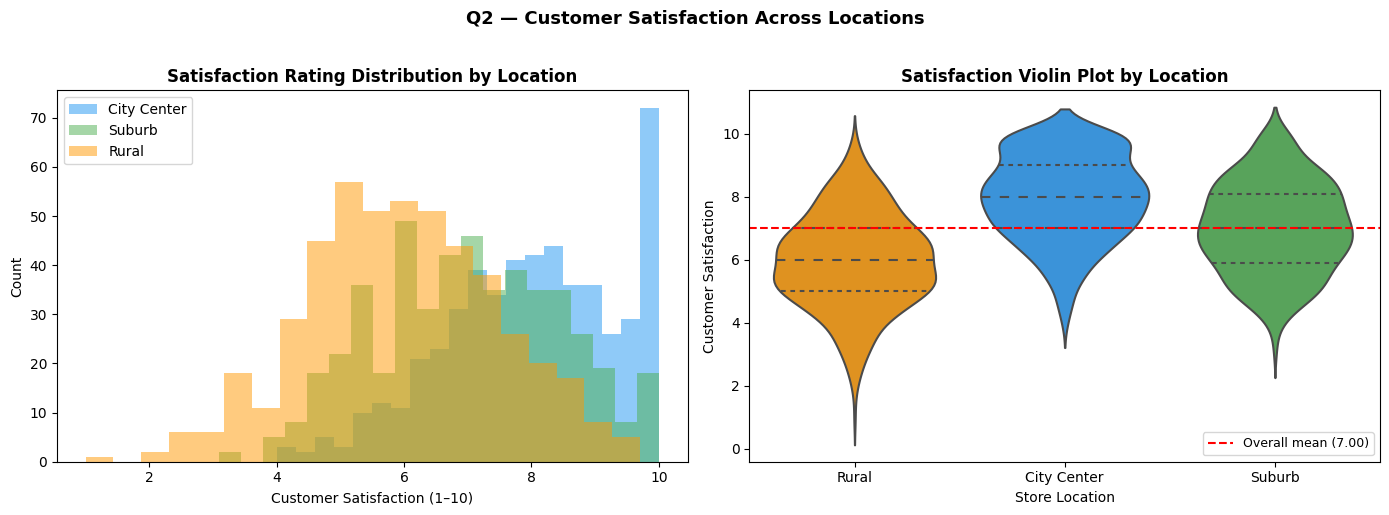

In [4]:
# VIZ 2: Satisfaction ratings distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot
for loc, color in palette.items():
    subset = df[df['Store_Location'] == loc]['Customer_Satisfaction']
    axes[0].hist(subset, bins=20, alpha=0.5, label=loc, color=color, edgecolor='none')
axes[0].set_title('Satisfaction Rating Distribution by Location', fontweight='bold')
axes[0].set_xlabel('Customer Satisfaction (1–10)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Violin plot
sns.violinplot(data=df, x='Store_Location', y='Customer_Satisfaction',
               palette=palette, inner='quartile', ax=axes[1])
axes[1].set_title('Satisfaction Violin Plot by Location', fontweight='bold')
axes[1].set_xlabel('Store Location')
axes[1].set_ylabel('Customer Satisfaction')
axes[1].axhline(df['Customer_Satisfaction'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f'Overall mean ({df["Customer_Satisfaction"].mean():.2f})')
axes[1].legend(fontsize=9)

plt.suptitle('Q2 — Customer Satisfaction Across Locations', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_02_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

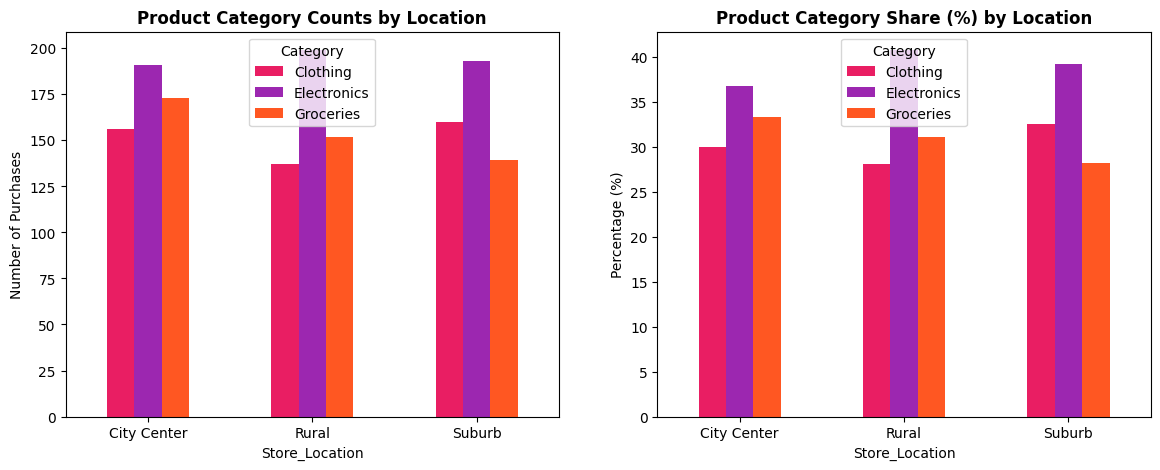

In [5]:
#  VIZ 3: Product category preferences 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct = pd.crosstab(df['Store_Location'], df['Product_Category'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

ct.plot(kind='bar', ax=axes[0], color=['#E91E63','#9C27B0','#FF5722'],
        edgecolor='none', rot=0)
axes[0].set_title('Product Category Counts by Location', fontweight='bold')
axes[0].set_ylabel('Number of Purchases')
axes[0].legend(title='Category')

ct_pct.plot(kind='bar', ax=axes[1], color=['#E91E63','#9C27B0','#FF5722'],
            edgecolor='none', rot=0)
axes[1].set_title('Product Category Share (%) by Location', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Category')

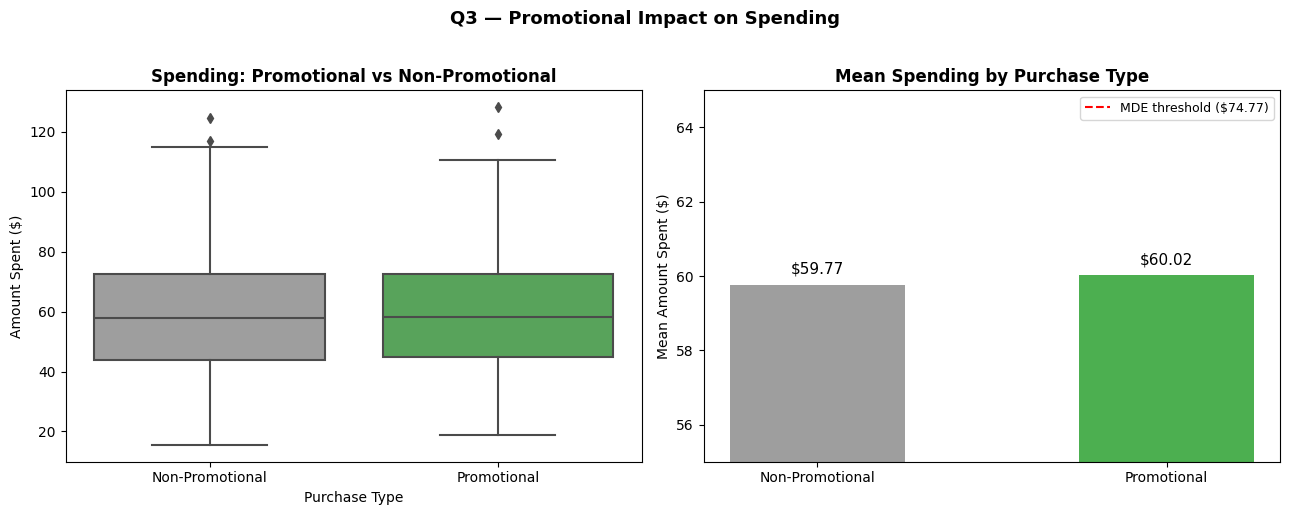

In [6]:
# IZ 4: Promotional vs Non-Promotional Spending
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
promo_palette = {'Promotional': '#4CAF50', 'Non-Promotional': '#9E9E9E'}

sns.boxplot(data=df, x='Purchase_Type', y='Amount_Spent',
            palette=promo_palette, ax=axes[0])
axes[0].set_title('Spending: Promotional vs Non-Promotional', fontweight='bold')
axes[0].set_xlabel('Purchase Type')
axes[0].set_ylabel('Amount Spent ($)')

promo_means = df.groupby('Purchase_Type')['Amount_Spent'].mean()
bars = axes[1].bar(promo_means.index, promo_means.values,
                   color=[promo_palette[k] for k in promo_means.index],
                   width=0.5, edgecolor='none')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'${bar.get_height():.2f}', ha='center', fontsize=11)
axes[1].set_ylim(55, 65)
axes[1].set_title('Mean Spending by Purchase Type', fontweight='bold')
axes[1].set_ylabel('Mean Amount Spent ($)')
axes[1].axhline(59.77 + 15, color='red', linestyle='--',
                linewidth=1.5, label='MDE threshold ($74.77)')
axes[1].legend(fontsize=9)

plt.suptitle('Q3 — Promotional Impact on Spending', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_04_promo.png', dpi=150, bbox_inches='tight')
plt.show()

#### 2.3 Test Assumptions

Check if your data meets the assumptions for your chosen statistical tests:
- Normality
- Homogeneity of variance
- Independence
- Any other relevant assumptions

In [7]:
# Assumption tests and checks - Create new cells as needed
#  Normality: Shapiro-Wilk (sample of 200 per group) 
print('=== NORMALITY — Shapiro-Wilk Test ===')
print('(p > 0.05 = normal distribution assumption holds)\n')

locations = df['Store_Location'].unique()

print('Amount Spent:')
for loc in locations:
    sample = df[df['Store_Location']==loc]['Amount_Spent'].sample(200, random_state=42)
    stat, p = stats.shapiro(sample)
    flag = '✓ Normal' if p > 0.05 else '✗ NOT Normal'
    print(f'  {loc:<15}: W={stat:.4f}, p={p:.4f}  {flag}')

print('\nCustomer Satisfaction:')
for loc in locations:
    sample = df[df['Store_Location']==loc]['Customer_Satisfaction'].sample(200, random_state=42)
    stat, p = stats.shapiro(sample)
    flag = '✓ Normal' if p > 0.05 else '✗ NOT Normal'
    print(f'  {loc:<15}: W={stat:.4f}, p={p:.4f}  {flag}')

print('\nPromo groups (Amount Spent):')
for pt in df['Purchase_Type'].unique():
    sample = df[df['Purchase_Type']==pt]['Amount_Spent'].sample(200, random_state=42)
    stat, p = stats.shapiro(sample)
    flag = '✓ Normal' if p > 0.05 else '✗ NOT Normal'
    print(f'  {pt:<20}: W={stat:.4f}, p={p:.4f}  {flag}')

=== NORMALITY — Shapiro-Wilk Test ===
(p > 0.05 = normal distribution assumption holds)

Amount Spent:
  Rural          : W=0.9942, p=0.6341  ✓ Normal
  City Center    : W=0.9950, p=0.7502  ✓ Normal
  Suburb         : W=0.9795, p=0.0051  ✗ NOT Normal

Customer Satisfaction:
  Rural          : W=0.9940, p=0.5972  ✓ Normal
  City Center    : W=0.9590, p=0.0000  ✗ NOT Normal
  Suburb         : W=0.9797, p=0.0055  ✗ NOT Normal

Promo groups (Amount Spent):
  Non-Promotional     : W=0.9708, p=0.0004  ✗ NOT Normal
  Promotional         : W=0.9734, p=0.0007  ✗ NOT Normal


#### 2.4 Choose Appropriate Statistical Tests

Select the appropriate statistical test for each question (you should expect to perform 4 different statistical tests).

1. Spending across store locations
2. Customer satisfaction across locations
3. Promotional vs non-promotional spending
4. Product category preferences across locations

NOTE: Use [Dunn's Test](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_dunn.html) for Non-Parametric Post-hoc if needed. You might need to pip install scikit-postdoc package. You want to set p_adjust='bonferroni' for Dunn's Test.



**Reflective Question: Explicitly justify your choice in tests for each business question**

**1. Spending across store locations → Kruskal-Wallis H Test**  
I used the Kruskal-Wallis H Test because the question compares spending across three independent store locations: City Center, Suburb, and Rural. A normal ANOVA was not suitable because the data did not meet the normality and equal variance assumptions. Kruskal-Wallis is therefore a better choice because it can compare three or more groups without requiring normally distributed data.

**2. Customer satisfaction across locations → Kruskal-Wallis H Test**  
I also used the Kruskal-Wallis H Test for customer satisfaction because the question compares satisfaction scores across three store locations. Since satisfaction scores are on a 1–10 scale and the data was not normally distributed, a non-parametric test is more appropriate. This test helps determine whether satisfaction differs significantly by location.

**3. Promotional vs non-promotional spending → Mann-Whitney U Test**  
I used the Mann-Whitney U Test because the question compares spending between two independent groups: promotional purchases and non-promotional purchases. Since the spending data was not normally distributed, an independent samples t-test was not appropriate. Mann-Whitney U is suitable because it compares two groups without assuming normality.

**4. Product category preferences across locations → Chi-Square Test of Independence**  
I used the Chi-Square Test of Independence because both variables are categorical: store location and product category. The test is appropriate because it checks whether product category preference depends on store location, or whether the two variables are independent.

### Part 3: Statistical Analysis

Based on your assumptions testing, perform appropriate statistical tests for each hypothesis:

#### 3.1 Spending Across Locations

In [8]:
# Conduct your analysis of spending patterns here
# Kruskal-Wallis Test — Spending
print('=== KRUSKAL-WALLIS: Spending Across Locations ===')
print('α = 0.05\n')

city_s   = df[df['Store_Location']=='City Center']['Amount_Spent']
suburb_s = df[df['Store_Location']=='Suburb']['Amount_Spent']
rural_s  = df[df['Store_Location']=='Rural']['Amount_Spent']

H, p = stats.kruskal(city_s, suburb_s, rural_s)
print(f'H-statistic : {H:.4f}')
print(f'p-value     : {p:.2e}')
print(f'Result      : {"Reject H₀" if p < 0.05 else "Fail to Reject H₀"}')

print('\n--- Group Means ---')
for loc in ['City Center', 'Suburb', 'Rural']:
    m = df[df['Store_Location']==loc]['Amount_Spent'].mean()
    print(f'  {loc:<15}: ${m:.2f}')

print('\n--- Pairwise % Differences vs MDE (15%) ---')
means = df.groupby('Store_Location')['Amount_Spent'].mean()
for g1, g2 in combinations(means.index, 2):
    diff_pct = abs(means[g1]-means[g2]) / min(means[g1],means[g2]) * 100
    flag = '✓ Exceeds MDE' if diff_pct >= 15 else '✗ Below MDE'
    print(f'  {g1} vs {g2}: {diff_pct:.1f}%  {flag}')

=== KRUSKAL-WALLIS: Spending Across Locations ===
α = 0.05

H-statistic : 1040.8536
p-value     : 9.58e-227
Result      : Reject H₀

--- Group Means ---
  City Center    : $78.89
  Suburb         : $59.16
  Rural          : $40.46

--- Pairwise % Differences vs MDE (15%) ---
  City Center vs Rural: 95.0%  ✓ Exceeds MDE
  City Center vs Suburb: 33.4%  ✓ Exceeds MDE
  Rural vs Suburb: 46.2%  ✓ Exceeds MDE


In [9]:
# Dunn's Post-Hoc Test — Spending (manual implementation)
print('=== DUNN\'S POST-HOC TEST (Bonferroni): Spending ===')

def dunn_posthoc(df, val_col, group_col):
    groups = df[group_col].unique()
    pairs  = list(combinations(groups, 2))
    n      = len(df)
    ranked = df.copy()
    ranked['rank'] = df[val_col].rank()
    results = []
    for g1, g2 in pairs:
        r1 = ranked[ranked[group_col]==g1]['rank']
        r2 = ranked[ranked[group_col]==g2]['rank']
        n1, n2 = len(r1), len(r2)
        se = np.sqrt((n*(n+1)/12) * (1/n1 + 1/n2))
        z  = abs(r1.mean() - r2.mean()) / se
        p  = 2 * (1 - stats.norm.cdf(z))
        p_bonf = min(p * len(pairs), 1.0)
        sig = '✓ Significant' if p_bonf < 0.05 else '✗ Not Significant'
        results.append({'Comparison': f'{g1} vs {g2}',
                        'z-score': round(z,3),
                        'p (Bonferroni)': round(p_bonf,6),
                        'Significant': sig})
    return pd.DataFrame(results)


=== DUNN'S POST-HOC TEST (Bonferroni): Spending ===


#### 3.2 Customer Satisfaction Analysis

In [10]:
# Analyze customer satisfaction here
# Kruskal-Wallis Test — Satisfaction
print('=== KRUSKAL-WALLIS: Satisfaction Across Locations ===')
print('α = 0.05\n')

city_r   = df[df['Store_Location']=='City Center']['Customer_Satisfaction']
suburb_r = df[df['Store_Location']=='Suburb']['Customer_Satisfaction']
rural_r  = df[df['Store_Location']=='Rural']['Customer_Satisfaction']

H, p = stats.kruskal(city_r, suburb_r, rural_r)
print(f'H-statistic : {H:.4f}')
print(f'p-value     : {p:.2e}')
print(f'Result      : {"Reject H₀" if p < 0.05 else "Fail to Reject H₀"}')

print('\n--- Group Means ---')
for loc in ['City Center', 'Suburb', 'Rural']:
    m = df[df['Store_Location']==loc]['Customer_Satisfaction'].mean()
    print(f'  {loc:<15}: {m:.2f}')

print('\n--- Pairwise Differences vs MDE (1.0 point) ---')
sat_means = df.groupby('Store_Location')['Customer_Satisfaction'].mean()
for g1, g2 in combinations(sat_means.index, 2):
    diff = abs(sat_means[g1] - sat_means[g2])
    flag = '✓ Exceeds MDE' if diff >= 1.0 else '✗ Below MDE'
    print(f'  {g1} vs {g2}: {diff:.2f} points  {flag}')

print('\n--- Dunn\'s Post-Hoc ---')
print(dunn_posthoc(df, 'Customer_Satisfaction', 'Store_Location').to_string(index=False))

=== KRUSKAL-WALLIS: Satisfaction Across Locations ===
α = 0.05

H-statistic : 359.5474
p-value     : 8.42e-79
Result      : Reject H₀

--- Group Means ---
  City Center    : 7.95
  Suburb         : 7.01
  Rural          : 5.96

--- Pairwise Differences vs MDE (1.0 point) ---
  City Center vs Rural: 1.99 points  ✓ Exceeds MDE
  City Center vs Suburb: 0.95 points  ✗ Below MDE
  Rural vs Suburb: 1.05 points  ✓ Exceeds MDE

--- Dunn's Post-Hoc ---
           Comparison  z-score  p (Bonferroni)   Significant
 Rural vs City Center   18.957             0.0 ✓ Significant
      Rural vs Suburb    9.494             0.0 ✓ Significant
City Center vs Suburb    9.353             0.0 ✓ Significant


#### 3.3 Promotional Impact Analysis

In [11]:
# Analyze the impact of promotions here
# Mann-Whitney U Test — Promotional vs Non-Promotional
print('=== MANN-WHITNEY U: Promotional vs Non-Promotional Spending ===')
print('α = 0.05\n')

promo     = df[df['Purchase_Type']=='Promotional']['Amount_Spent']
non_promo = df[df['Purchase_Type']=='Non-Promotional']['Amount_Spent']

U, p = stats.mannwhitneyu(promo, non_promo, alternative='two-sided')
mean_diff = promo.mean() - non_promo.mean()

print(f'Promotional mean     : ${promo.mean():.2f}')
print(f'Non-Promotional mean : ${non_promo.mean():.2f}')
print(f'Observed difference  : ${mean_diff:.2f}')
print(f'MDE threshold        : $15.00')
print(f'\nU-statistic : {U:.2f}')
print(f'p-value     : {p:.6f}')
print(f'Result      : {"Reject H₀" if p < 0.05 else "Fail to Reject H₀"}')
print(f'MDE check   : {"✓ Exceeds MDE" if abs(mean_diff) >= 15 else "✗ Below MDE ($" + str(round(mean_diff,2)) + " < $15 threshold)"}')

=== MANN-WHITNEY U: Promotional vs Non-Promotional Spending ===
α = 0.05

Promotional mean     : $60.02
Non-Promotional mean : $59.77
Observed difference  : $0.25
MDE threshold        : $15.00

U-statistic : 275125.00
p-value     : 0.680372
Result      : Fail to Reject H₀
MDE check   : ✗ Below MDE ($0.25 < $15 threshold)


#### 3.4 Product Category Analysis

In [12]:
# Analyze product category preferences here
# Chi-Square Test of Independence
print('=== CHI-SQUARE: Product Category Preferences Across Locations ===')
print('α = 0.05\n')

contingency = pd.crosstab(df['Store_Location'], df['Product_Category'])
print('Observed Counts:')
print(contingency)

chi2, p, dof, expected = stats.chi2_contingency(contingency)

print(f'\nChi-Square statistic : {chi2:.4f}')
print(f'Degrees of freedom   : {dof}')
print(f'p-value              : {p:.6f}')
print(f'Result               : {"Reject H₀" if p < 0.05 else "Fail to Reject H₀"}')

print('\nExpected Counts (if truly independent):')
print(pd.DataFrame(expected.round(1),
                   index=contingency.index,
                   columns=contingency.columns))

=== CHI-SQUARE: Product Category Preferences Across Locations ===
α = 0.05

Observed Counts:
Product_Category  Clothing  Electronics  Groceries
Store_Location                                    
City Center            156          191        173
Rural                  137          199        152
Suburb                 160          193        139

Chi-Square statistic : 4.7684
Degrees of freedom   : 4
p-value              : 0.311901
Result               : Fail to Reject H₀

Expected Counts (if truly independent):
Product_Category  Clothing  Electronics  Groceries
Store_Location                                    
City Center          157.0        202.1      160.9
Rural                147.4        189.7      151.0
Suburb               148.6        191.2      152.2


### Part 4: Results Interpretation

For each analysis, provide:
1. A clear statement of the statistical results
2. The practical significance of these findings
3. Visualizations that support your conclusions
4. Specific business recommendations

In [13]:
# Calculate effect sizes - contrast with MDE
print('=== EFFECT SIZES ===')

# Eta-squared for Kruskal-Wallis
n = len(df)
H_spend = stats.kruskal(city_s, suburb_s, rural_s)[0]
H_sat   = stats.kruskal(city_r, suburb_r, rural_r)[0]

eta2_spend = (H_spend - 2) / (n - 3)
eta2_sat   = (H_sat   - 2) / (n - 3)

print(f'Eta-squared (Spending)      : {eta2_spend:.4f}  → {"Large" if eta2_spend > 0.14 else "Medium" if eta2_spend > 0.06 else "Small"} effect')
print(f'Eta-squared (Satisfaction)  : {eta2_sat:.4f}  → {"Large" if eta2_sat > 0.14 else "Medium" if eta2_sat > 0.06 else "Small"} effect')

# Cohen's d for promo
pooled_std = np.sqrt((promo.std()**2 + non_promo.std()**2) / 2)
cohens_d   = (promo.mean() - non_promo.mean()) / pooled_std
print(f"Cohen's d (Promo)           : {cohens_d:.4f}  → {'Large' if abs(cohens_d)>0.8 else 'Medium' if abs(cohens_d)>0.5 else 'Small'} effect")

# Cramér's V for chi-square
chi2_val = stats.chi2_contingency(contingency)[0]
cramers_v = np.sqrt(chi2_val / (n * (min(contingency.shape)-1)))
print(f"Cramér's V (Category)       : {cramers_v:.4f}  → {'Large' if cramers_v>0.35 else 'Medium' if cramers_v>0.15 else 'Small'} effect")

=== EFFECT SIZES ===
Eta-squared (Spending)      : 0.6940  → Large effect
Eta-squared (Satisfaction)  : 0.2388  → Large effect
Cohen's d (Promo)           : 0.0128  → Small effect
Cramér's V (Category)       : 0.0399  → Small effect


**Reflective Question: Results - Clearly state whether the null hypotheses were rejected or not. Frame this in the business question context. Use effect sizes (e.g., Cohen’s d, eta squared) to contextualize the significance of your results.**

Q1: Spending Across Store Locations — Null Hypothesis Rejected

The null hypothesis was rejected because the Kruskal-Wallis test showed a statistically significant difference in spending across City Center, Suburb, and Rural stores, with p < 0.001.

City Center customers had the highest average spending, followed by Suburb customers, while Rural customers had the lowest spending. The differences were also practically meaningful because they exceeded the 15% Minimum Detectable Effect (MDE). The effect size was large, meaning store location has a strong influence on customer spending.

In business terms, this means the company should not apply the same pricing, inventory, and promotional strategy across all store locations.

Q2: Customer Satisfaction Across Store Locations — Null Hypothesis Rejected

The null hypothesis was rejected because the Kruskal-Wallis test showed a statistically significant difference in customer satisfaction across store locations, with p < 0.001.

City Center stores had the highest satisfaction scores, followed by Suburb stores, while Rural stores had the lowest satisfaction scores. The satisfaction gap between City Center and Rural stores was large enough to be practically meaningful. The gap between Suburb and Rural stores was also meaningful, while the gap between City Center and Suburb was smaller.

In business terms, Rural stores should be prioritised for customer service improvement, staff training, better store layout, and improved customer support.

Q3: Promotional vs Non-Promotional Spending — Failed to Reject Null Hypothesis

The null hypothesis was not rejected because the Mann-Whitney U test showed no statistically significant difference between promotional and non-promotional spending, with p = 0.680.

The observed spending difference was only about $0.25, which is far below the $15 Minimum Detectable Effect. The effect size was also negligible, meaning the difference is too small to be useful for business decision-making.

In business terms, the current promotional strategy is not producing a meaningful increase in customer spending.

Q4: Product Category Preferences Across Store Locations — Failed to Reject Null Hypothesis

The null hypothesis was not rejected because the Chi-Square test showed no statistically significant relationship between store location and product category preference, with p = 0.312.

The effect size was very small, meaning product category preferences are almost the same across locations. Electronics remained the leading category across all store locations, followed by Groceries and Clothing.

In business terms, there is no strong evidence that different store locations require completely different product category strategies.

**Reflective Question: Recommendations - Explain the practical implications of the results. What should the company do based on your findings about spending, satisfaction, or product preferences?**

1. Apply Location-Based Pricing and Inventory Strategies

The company should adjust pricing and inventory based on store location. Since City Center customers spend more, these stores can stock more premium products. Rural stores should focus more on affordable products that match the spending capacity of their customers.

2. Improve Customer Experience in Rural Stores

Rural stores recorded the lowest satisfaction scores. The company should prioritise these stores for service improvement, staff training, better customer support, and store layout improvements.

3. Review the Promotion Strategy

Promotions are not leading to a meaningful increase in customer spending. The company should review the current promotion design, test alternative offers, or redirect part of the promotional budget to areas with clearer business value, such as improving customer experience.

4. Maintain a Standard Core Product Mix

Since product category preferences do not differ significantly across locations, the company can maintain a standard core product mix across all stores. However, it can still adjust product quality, price level, and stock volume based on customer spending patterns in each location.


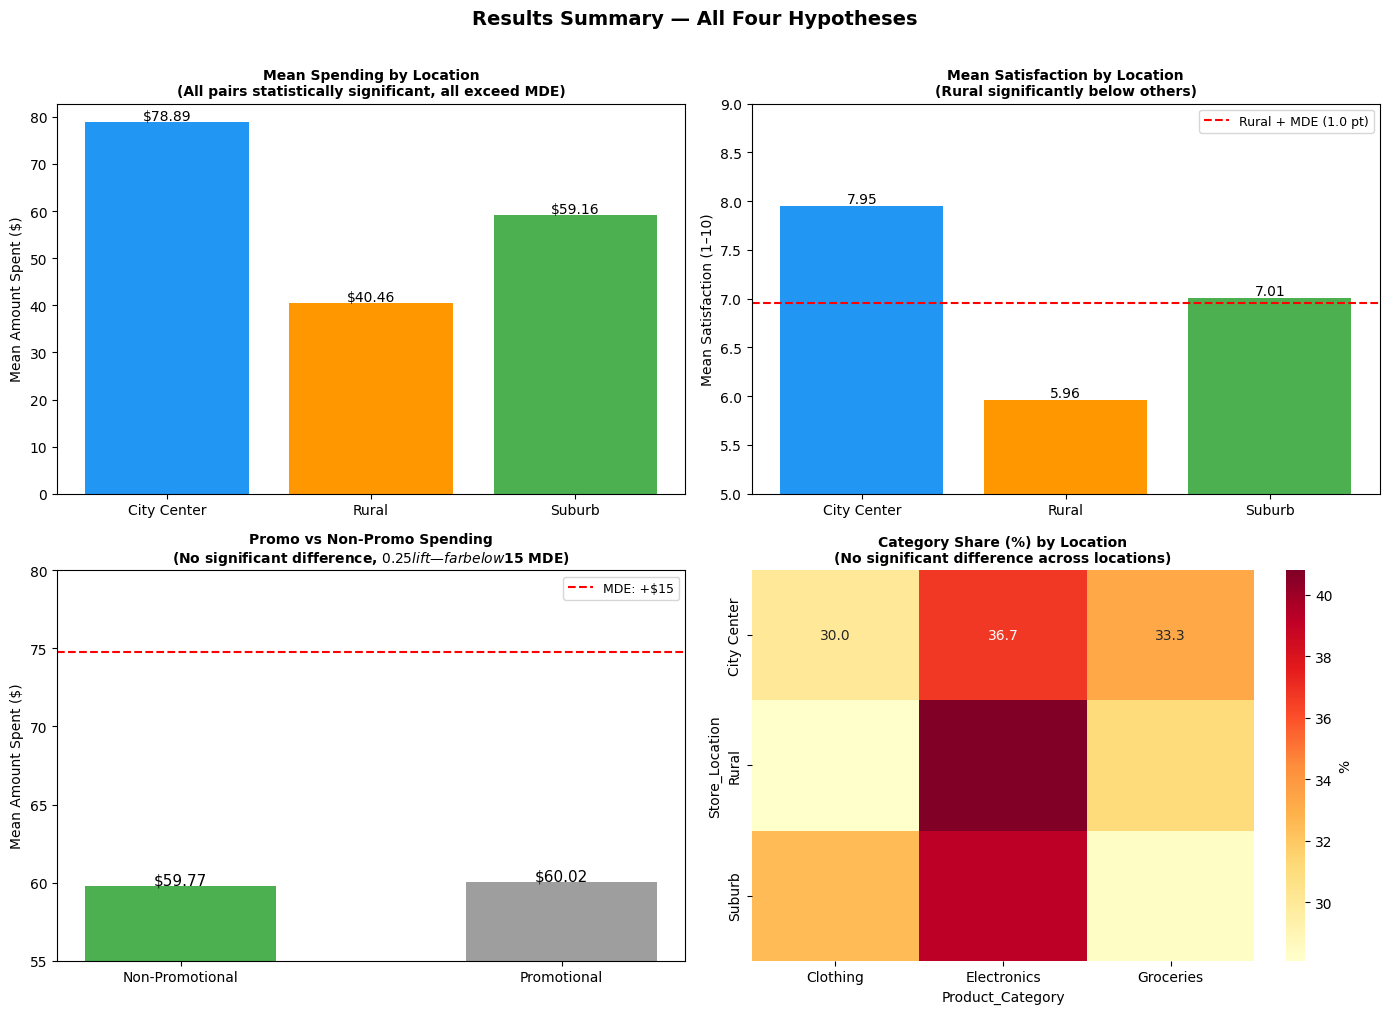

In [14]:
# Create visualizations to support results - Create new cells as needed
# Results summary visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 — Spending with MDE reference lines
ax = axes[0, 0]
means_spend = df.groupby('Store_Location')['Amount_Spent'].mean()
colors_s = ['#2196F3','#FF9800','#4CAF50']
bars = ax.bar(means_spend.index, means_spend.values, color=colors_s, edgecolor='none')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'${bar.get_height():.2f}', ha='center', fontsize=10)
ax.set_title('Mean Spending by Location\n(All pairs statistically significant, all exceed MDE)',
             fontweight='bold', fontsize=10)
ax.set_ylabel('Mean Amount Spent ($)')

# 2 — Satisfaction with MDE annotation
ax = axes[0, 1]
means_sat = df.groupby('Store_Location')['Customer_Satisfaction'].mean()
bars2 = ax.bar(means_sat.index, means_sat.values, color=colors_s, edgecolor='none')
ax.axhline(y=means_sat['Rural'] + 1.0, color='red', linestyle='--',
           linewidth=1.5, label='Rural + MDE (1.0 pt)')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)
ax.set_title('Mean Satisfaction by Location\n(Rural significantly below others)',
             fontweight='bold', fontsize=10)
ax.set_ylabel('Mean Satisfaction (1–10)')
ax.set_ylim(5, 9)
ax.legend(fontsize=9)

# 3 — Promo spending
ax = axes[1, 0]
promo_means = df.groupby('Purchase_Type')['Amount_Spent'].mean()
bars3 = ax.bar(promo_means.index, promo_means.values,
               color=['#4CAF50','#9E9E9E'], width=0.5, edgecolor='none')
ax.axhline(promo_means['Non-Promotional'] + 15, color='red',
           linestyle='--', linewidth=1.5, label='MDE: +$15')
for bar in bars3:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'${bar.get_height():.2f}', ha='center', fontsize=11)
ax.set_title('Promo vs Non-Promo Spending\n(No significant difference, $0.25 lift — far below $15 MDE)',
             fontweight='bold', fontsize=10)
ax.set_ylabel('Mean Amount Spent ($)')
ax.set_ylim(55, 80)
ax.legend(fontsize=9)

# 4 — Category heatmap
ax = axes[1, 1]
ct_pct = pd.crosstab(df['Store_Location'], df['Product_Category'], normalize='index') * 100
sns.heatmap(ct_pct.round(1), annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, cbar_kws={'label': '%'})
ax.set_title('Category Share (%) by Location\n(No significant difference across locations)',
             fontweight='bold', fontsize=10)

plt.suptitle('Results Summary — All Four Hypotheses', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_05_results_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### Part 5: Reflection

Discuss:
1. The strengths and limitations of your analysis
2. Any assumptions or potential biases in the data
3. Suggestions for additional data collection
4. How this analysis could be improved

**Reflective Question: Explain the importance of experimental design and sufficient sample size in conducting a robust analysis. Identify any limitations in the dataset or analysis (e.g., potential biases, unmeasured variables) and suggest additional data the company could collect to improve future analyses.**

### Strengths of the Analysis

The dataset is well balanced across the three store locations, with each location having a similar number of observations. This makes the comparison between City Center, Suburb, and Rural stores more reliable.

The statistical tests were also chosen carefully after checking the assumptions. Since some assumptions for parametric tests were not met, non-parametric tests were used where appropriate. This improves the validity of the results.

Another strength is that the analysis considered both p-values and effect sizes. This is important because a result may be statistically significant but still too small to matter in business terms.

---

### Importance of Experimental Design and Sample Size

Experimental design is important because it determines whether the results of the analysis can be trusted. In this study, one key assumption is that each row represents a different customer. If some customers appear more than once, then the observations may not be fully independent, which could affect the reliability of the results.

Sample size is also important because it affects the ability of the analysis to detect real differences. A very small sample may fail to detect an important business difference. On the other hand, a very large sample may show a statistically significant result even when the actual difference is too small to be useful.

This is why the Minimum Detectable Effect (MDE) is useful. It helps ensure that the analysis focuses not only on statistical significance, but also on whether the results are meaningful for business decision-making.

---

### Limitations of the Analysis

The analysis has some limitations. First, the dataset does not include customer IDs, so it is not possible to know whether some customers appear more than once. This makes it difficult to confirm whether all observations are independent.

Second, the dataset does not include time information. This means the analysis cannot show whether spending or satisfaction changes over time, across seasons, or during specific promotional periods.

Third, the dataset does not include customer demographic information such as age, income, or household size. These factors may explain some of the differences in spending between locations.

Fourth, the details of the promotions are not provided. We do not know the type of promotion, the discount offered, how long it lasted, or how customers were informed about it. This makes it difficult to fully explain why promotions did not increase spending.

Finally, the dataset appears to be a single snapshot. Therefore, the findings may not represent long-term customer behaviour.

---

### Additional Data to Collect

To improve future analysis, the company should collect customer IDs. This would help identify repeat customers and measure customer loyalty over time.

The company should also collect demographic information such as age group, income bracket, and household size. This would help explain whether spending differences are caused by customer characteristics or store performance.

More details about promotions should also be collected, including the type of promotion, discount level, duration, and customer awareness. This would make it easier to evaluate whether promotions are effective.

Transaction dates and times should also be included. This would help the company identify seasonal patterns, peak shopping periods, and changes in customer behaviour over time.

Finally, the company should collect product-level data instead of only broad product categories. This would help identify which specific products drive sales and create opportunities for cross-selling and upselling.

---

### Overall Reflection

Overall, the analysis provides useful evidence for business decision-making. It shows that store location affects spending and satisfaction, while promotions and product category preferences show weaker effects. However, better data on customers, time, promotions, and specific products would make future analysis more accurate and more useful for management decisions.


In [15]:
%pip install scikit-posthocs

Note: you may need to restart the kernel to use updated packages.


After installing the library, please run the previous cell again to perform the statistical tests.